---
numbering: false
---

# 2.2: Orthonormal bases in ℝ²

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import sys

_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly

BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'
ANNOTATION_SIZE = 24


def base2(xrange=(-5, 6), yrange=(-5, 5), width=700, height=580, tick=1):
    fig = style_plotly(go.Figure(), renderer='png')
    fig.update_layout(width=width, height=height, showlegend=False,
                      font=dict(size=17), margin=dict(l=55, r=30, t=30, b=50))
    fig.update_xaxes(title='x', range=xrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain', scaleanchor='y', scaleratio=1)
    fig.update_yaxes(title='y', range=yrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain')
    return fig


def line2(fig, start, end, color=BLUE, dash='solid', width=2):
    fig.add_trace(go.Scatter(x=[start[0], end[0]], y=[start[1], end[1]], mode='lines',
                            line=dict(color=color, width=width, dash=dash),
                            hoverinfo='skip', showlegend=False))


def label2(fig, xy, label, dx=0, dy=0, color='black'):
    # MathJax needs its own size command when exporting math labels to PNG.
    if label.startswith('$') and label.endswith('$'):
        label = r'$\Large ' + label[1:]
    fig.add_annotation(x=float(xy[0])+dx, y=float(xy[1])+dy, text=label, showarrow=False,
                       font=dict(family='Palatino', color=color, size=ANNOTATION_SIZE))


def point2(fig, xy, label=None, dx=0.35, dy=0.35):
    fig.add_trace(go.Scatter(x=[xy[0]], y=[xy[1]], mode='markers',
                            marker=dict(color='black', size=7), hoverinfo='skip'))
    if label: label2(fig, xy, '$' + label.replace('−', '-') + '$', dx, dy)


def vec2(fig, end, label=None, color=BLUE, start=(0, 0), dx=0.3, dy=0.3, width=4):
    # Match Chapter 1.4: a colored shaft, arrowhead, and midpoint math label.
    line2(fig, start, end, color=color, width=width)
    fig.add_annotation(x=float(end[0]), y=float(end[1]), ax=float(start[0]), ay=float(start[1]),
                       xref='x', yref='y', axref='x', ayref='y', showarrow=True,
                       text='', arrowhead=3, arrowsize=1.2, arrowwidth=3, arrowcolor=color)
    if label:
        midpoint = (np.asarray(start, dtype=float) + np.asarray(end, dtype=float)) / 2
        label2(fig, midpoint, label, dx, dy, color=color)


def square2(fig, corner, along, perp, size=0.3):
    corner=np.asarray(corner,dtype=float)
    u=np.asarray(along,dtype=float); u=u/np.linalg.norm(u)*size
    v=np.asarray(perp,dtype=float); v=v/np.linalg.norm(v)*size
    line2(fig,corner+u,corner+u+v,'gray',width=1.5)
    line2(fig,corner+v,corner+u+v,'gray',width=1.5)

In [Chapter 1.4](../ch01/01-04.ipynb), we wrote vectors as linear combinations of the standard basis vectors. Could we use a different pair of directions? In this section, we'll see why perpendicular unit vectors make this especially convenient.

## The standard basis

Recall the standard basis vectors from [Chapter 1.4](../ch01/01-04.ipynb):

$$
\vec e_1=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\vec e_2=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

Every vector in $\mathbb R^2$ is a linear combination of these two vectors. Its entries give the coefficients.

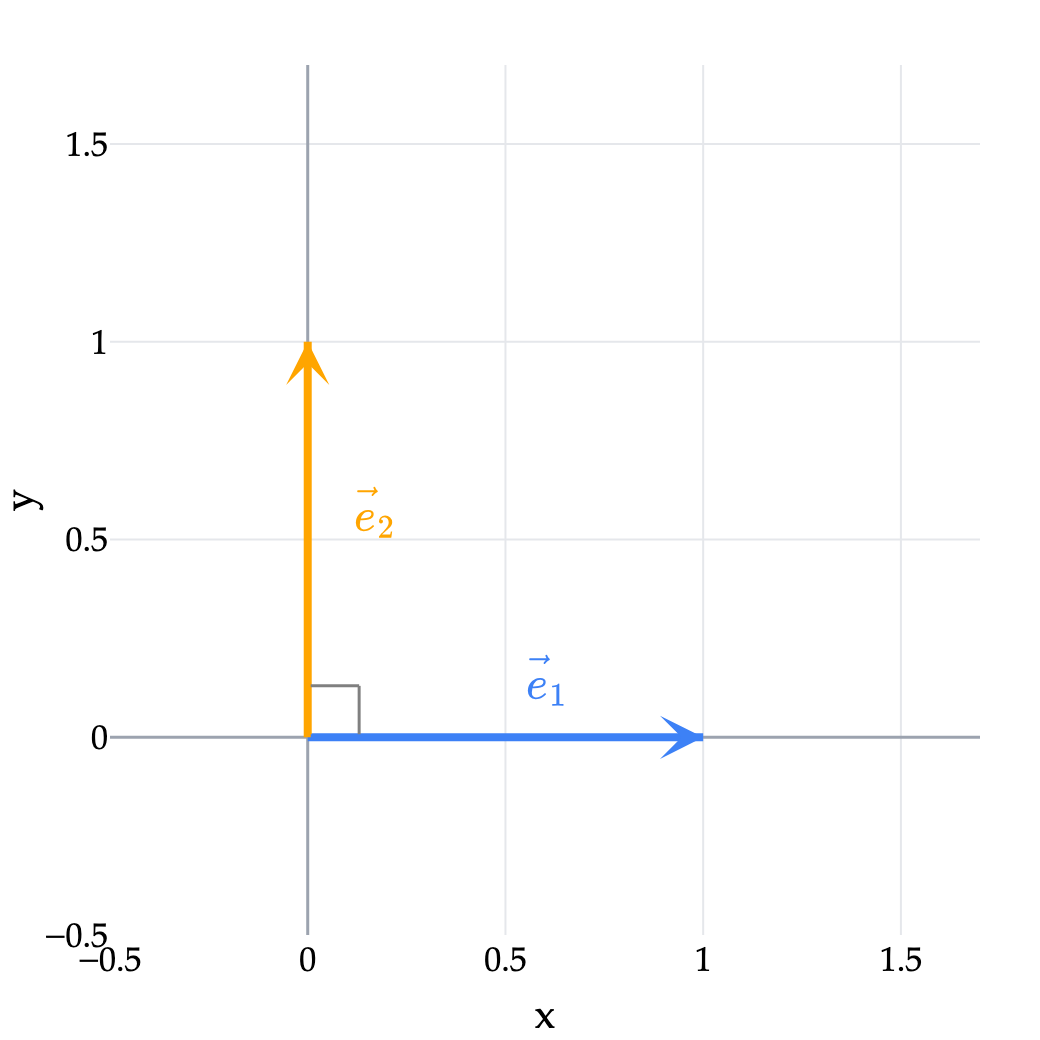

In [2]:
fig=base2((-0.5,1.7),(-0.5,1.7),width=520,height=520,tick=0.5)
vec2(fig,(1,0),r"$\vec e_1$",BLUE,dx=0.1,dy=0.16,width=4)
vec2(fig,(0,1),r"$\vec e_2$",ORANGE,dx=0.17,dy=0.08,width=4)
square2(fig,(0,0),(1,0),(0,1),0.13)
fig.show(scale=2)

```{figure} #plot-22-4
:label: fig-plot-22-4
:class: course-caption
:alt: The standard basis vectors in $\mathbb{R}^2$.

The standard basis vectors in $\mathbb{R}^2$.
```

For example,

$$
\begin{bmatrix}
5\\
7
\end{bmatrix}
=
\begin{bmatrix}
5\\
0
\end{bmatrix}
+
\begin{bmatrix}
0\\
7
\end{bmatrix}
=
5
\begin{bmatrix}
1\\
0
\end{bmatrix}
+
7
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
5\vec e_1+7\vec e_2.
$$

To do geometry in $\mathbb{R}^2$, it is useful to consider other such pairs of
vectors. The key properties of $(\vec e_1,\vec e_2)$ are:

1. length one,
1. orthogonal to each other.

These two properties will let us find coefficients using dot products, even when the directions are tilted.

Recall from [Chapter 1.5](../ch01/01-05.ipynb) that a **unit vector** has length one. We can turn any nonzero vector $\vec w$ into a unit vector by dividing by its length: $\vec w/\lVert\vec w\rVert$.

---

## Building an orthonormal basis

First, let's check the lengths of two vectors.

The vector

$$
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix}
$$

has length one since

$$
\sqrt{\left(\frac45\right)^2+\left(\frac35\right)^2}
=
\sqrt{\frac{16}{25}+\frac{9}{25}}
=
1.
$$

A unit vector can point in a different direction. For example, the vector

$$
\begin{bmatrix}
\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

has length one since

$$
\sqrt{
\left(\frac{1}{\sqrt{2}}\right)^2+
\left(-\frac{1}{\sqrt{2}}\right)^2
}
=
\sqrt{\frac12+\frac12}
=
1.
$$

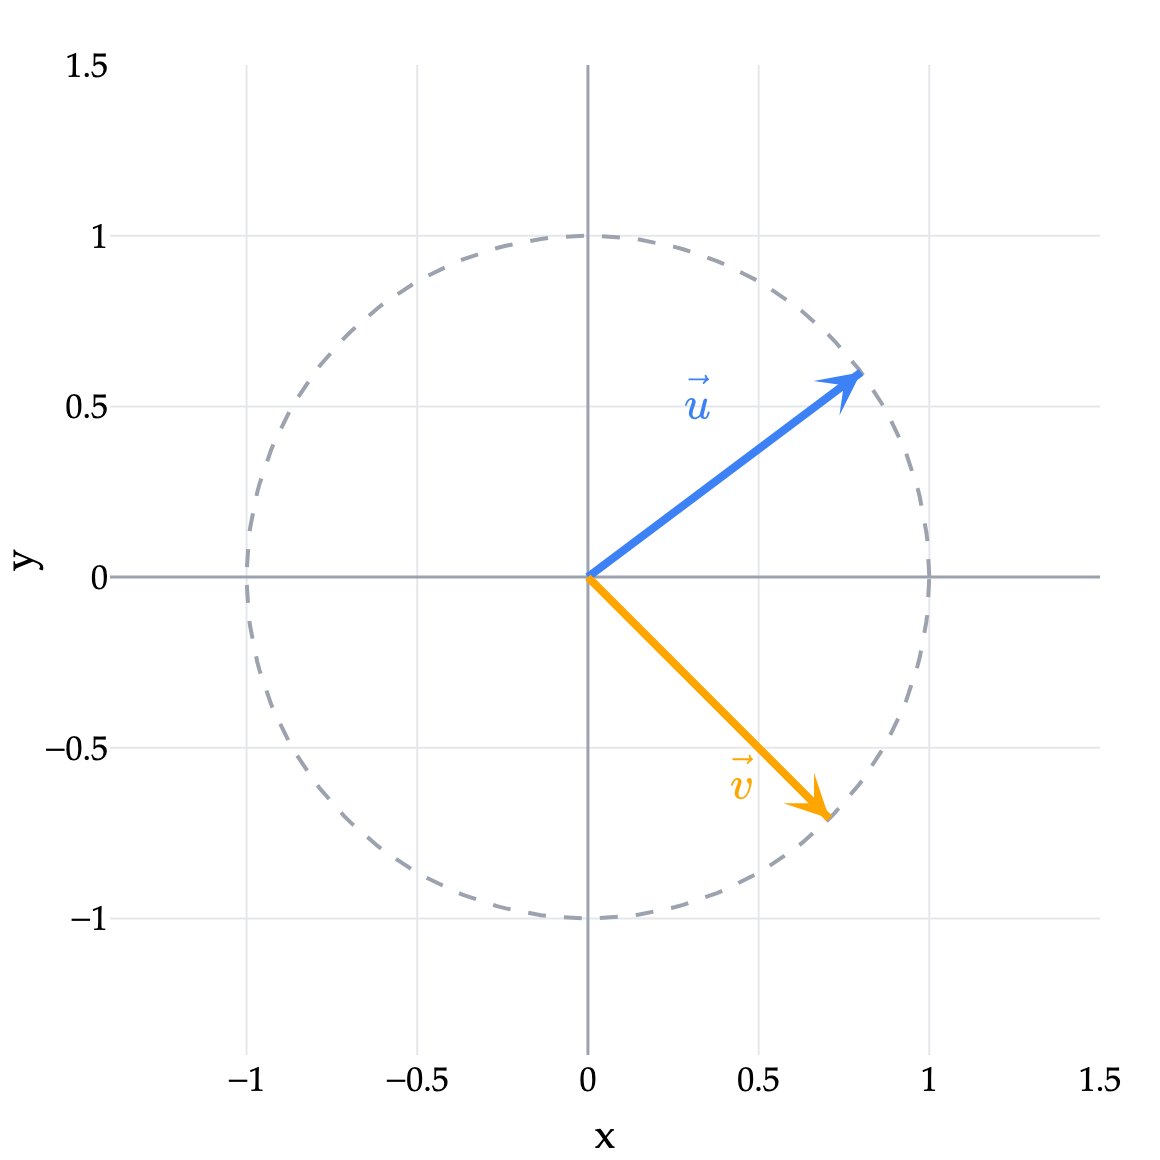

In [3]:
fig=base2((-1.4,1.5),(-1.4,1.5),width=580,height=580,tick=0.5)
t=np.linspace(0,2*np.pi,240)
fig.add_trace(go.Scatter(x=np.cos(t),y=np.sin(t),mode='lines',line=dict(color='#9ca3af',width=2,dash='dash'),hoverinfo='skip'))
vec2(fig,(4/5,3/5),r"$\vec u$",BLUE,dx=-0.08,dy=0.24,width=4)
vec2(fig,(1/np.sqrt(2),-1/np.sqrt(2)),r"$\vec v$",ORANGE,dx=0.1,dy=-0.22,width=4)
fig.show(scale=2)

```{figure} #plot-22-8
:label: fig-plot-22-8
:class: course-caption
:alt: Examples of unit vectors in $\mathbb{R}^2$: $\vec u=\begin{bmatrix}4/5\\3/5\end{bmatrix}$ and $\vec v=\begin{bmatrix}1/\sqrt{2}\\-1/\sqrt{2}\end{bmatrix}$. These vectors both have length one, but they are not orthogonal to each other.

Examples of unit vectors in $\mathbb{R}^2$: $\vec u=\begin{bmatrix}4/5\\3/5\end{bmatrix}$ and $\vec v=\begin{bmatrix}1/\sqrt{2}\\-1/\sqrt{2}\end{bmatrix}$. These vectors both have length one, but they are not orthogonal to each other.
```

To make an orthonormal basis, we need two unit vectors that are also perpendicular. Let

$$
\vec u_1=
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix},
\qquad
\vec u_2=
\begin{bmatrix}
-\frac35\\[2pt]
\frac45
\end{bmatrix}.
$$

Both vectors have length one, and their dot product is

$$
\vec u_1\cdot\vec u_2=\frac45\left(-\frac35\right)+\frac35\left(\frac45\right)=0.
$$

By [Chapter 1.6](../ch01/01-06.ipynb), they are orthogonal. This pair is an **orthonormal basis** of $\mathbb R^2$.

:::{note} Definition: Orthonormal basis in $\mathbb R^2$
An **orthonormal basis** of $\mathbb R^2$ is a pair of unit vectors that are orthogonal to each other.
:::

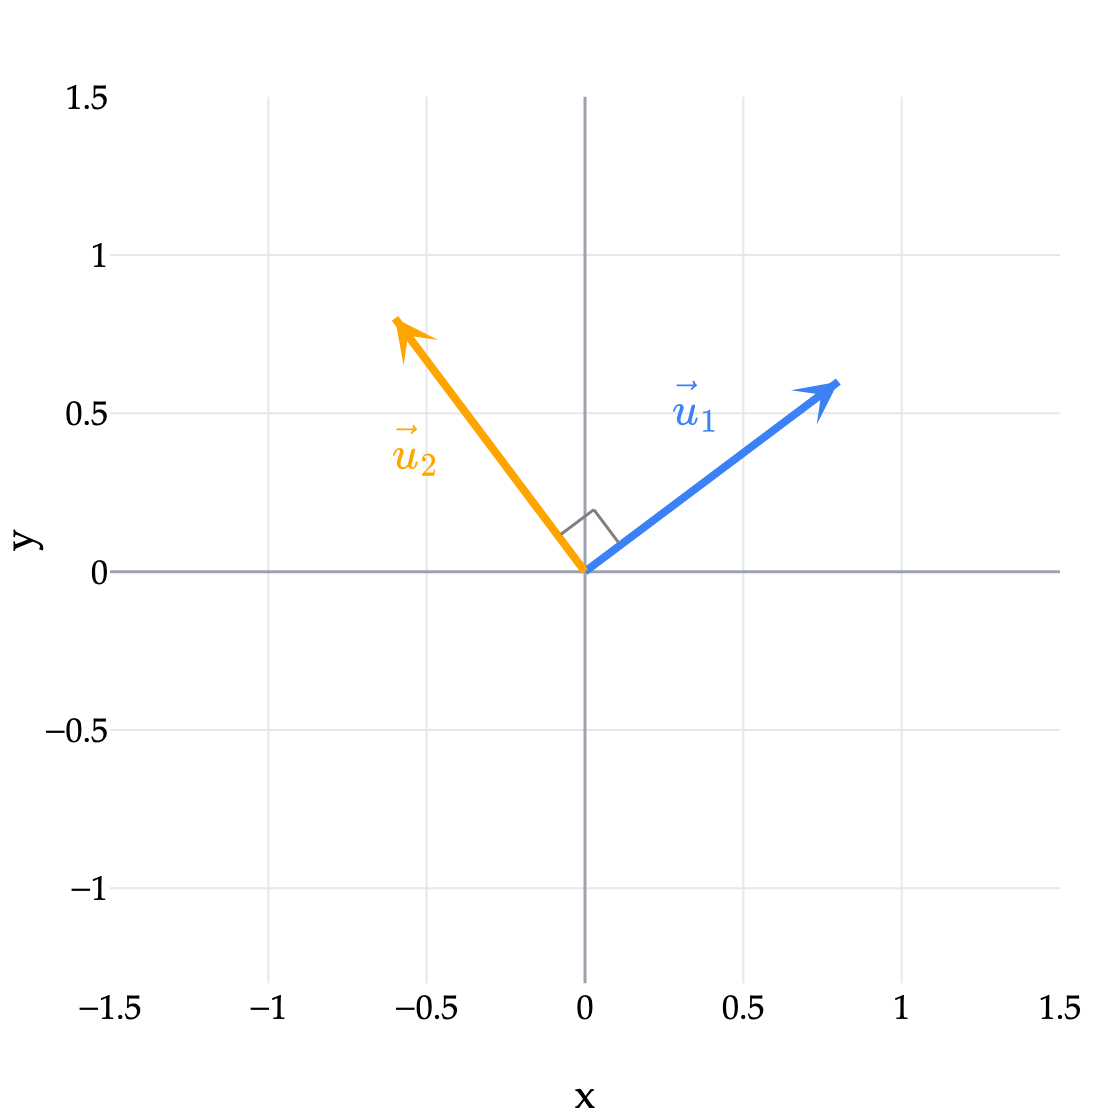

In [4]:
fig=base2((-1.5,1.5),(-1.3,1.5),width=560,height=560,tick=0.5)
u1=np.array([4/5,3/5]); u2=np.array([-3/5,4/5])
vec2(fig,u1,r"$\vec u_1$",BLUE,dx=-0.05,dy=0.24,width=4)
vec2(fig,u2,r"$\vec u_2$",ORANGE,dx=-0.24,dy=0.0,width=4)
square2(fig,(0,0),u1,u2,0.14)
fig.show(scale=2)

```{figure} #plot-22-11
:label: fig-plot-22-11
:class: course-caption
:alt: The pair $(\vec u_1,\vec u_2)$ is an orthonormal basis of $\mathbb{R}^2$.

The pair $(\vec u_1,\vec u_2)$ is an orthonormal basis of $\mathbb{R}^2$.
```

We can choose a different pair of perpendicular unit directions. Let

$$
\vec w_1=
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
\frac{1}{\sqrt{2}}
\end{bmatrix},
\qquad
\vec w_2=
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}.
$$

Each vector has squared length $1/2+1/2=1$, and

$$\vec w_1\cdot\vec w_2=\frac12-\frac12=0.$$

So $(\vec w_1,\vec w_2)$ is also an orthonormal basis. There are many choices of orthonormal basis, just as there are many choices of direction vector for a line.

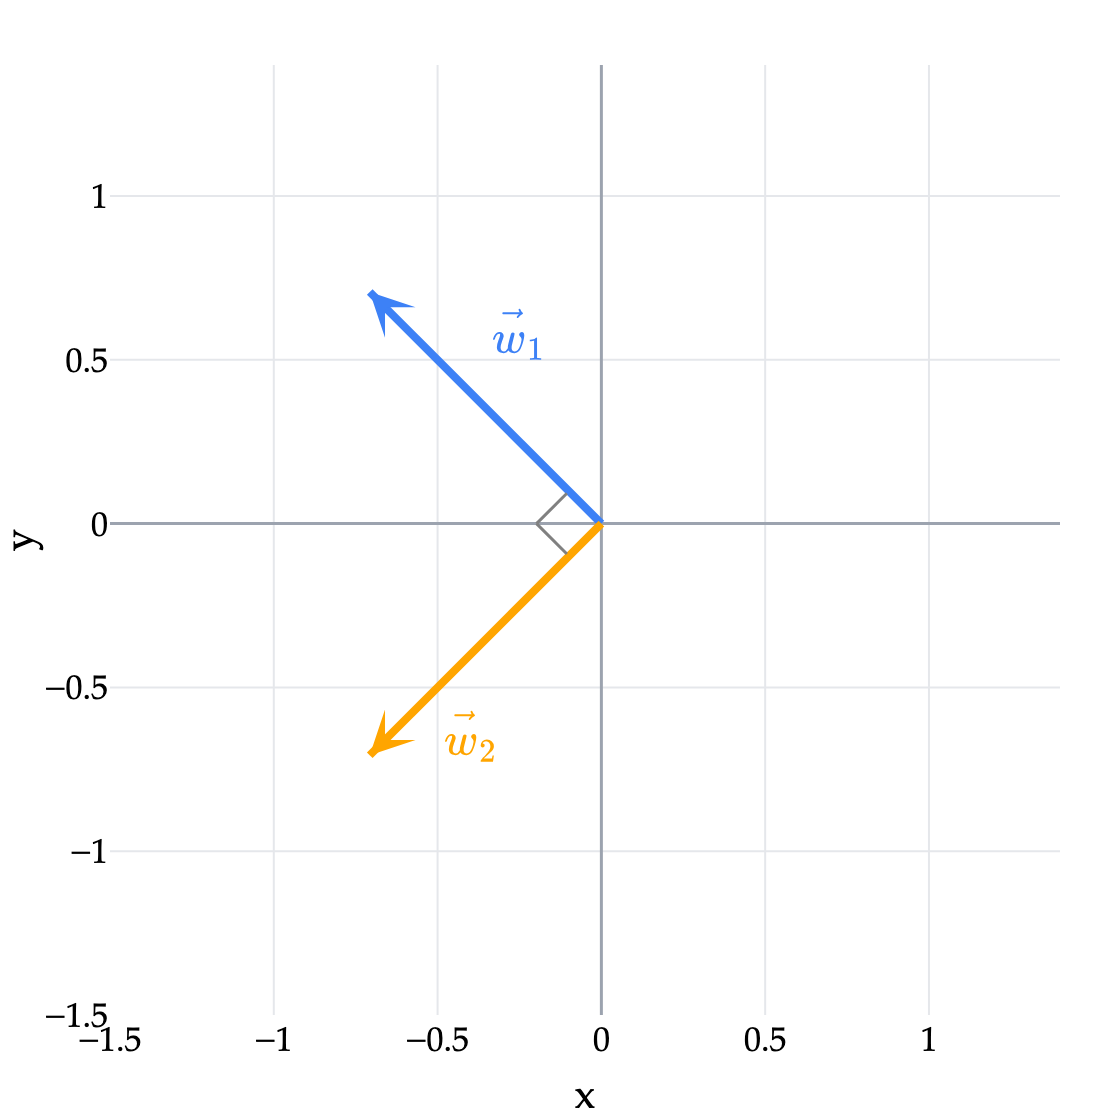

In [5]:
fig=base2((-1.5,1.4),(-1.5,1.4),width=560,height=560,tick=0.5)
w1=np.array([-1,1])/np.sqrt(2); w2=np.array([-1,-1])/np.sqrt(2)
vec2(fig,w1,r"$\vec w_1$",BLUE,dx=0.1,dy=0.24,width=4)
vec2(fig,w2,r"$\vec w_2$",ORANGE,dx=-0.05,dy=-0.28,width=4)
square2(fig,(0,0),w1,w2,0.14)
fig.show(scale=2)

```{figure} #plot-22-14
:label: fig-plot-22-14
:class: course-caption
:alt: An orthonormal basis is not unique.

An orthonormal basis is not unique.
```

---

## Finding coefficients using dot products

An orthonormal basis gives us two perpendicular directions. Every vector can be written uniquely as a sum of multiples of those directions. How can we find the two coefficients?

Let $\vec u_1,\vec u_2$ be an orthonormal basis of $\mathbb{R}^2$.

Let $\vec v$ be any vector in $\mathbb{R}^2$.

Then

$$
\vec v=a\vec u_1+b\vec u_2
$$

for some scalars $a,b$. The figure below shows this decomposition by completing a rectangle.

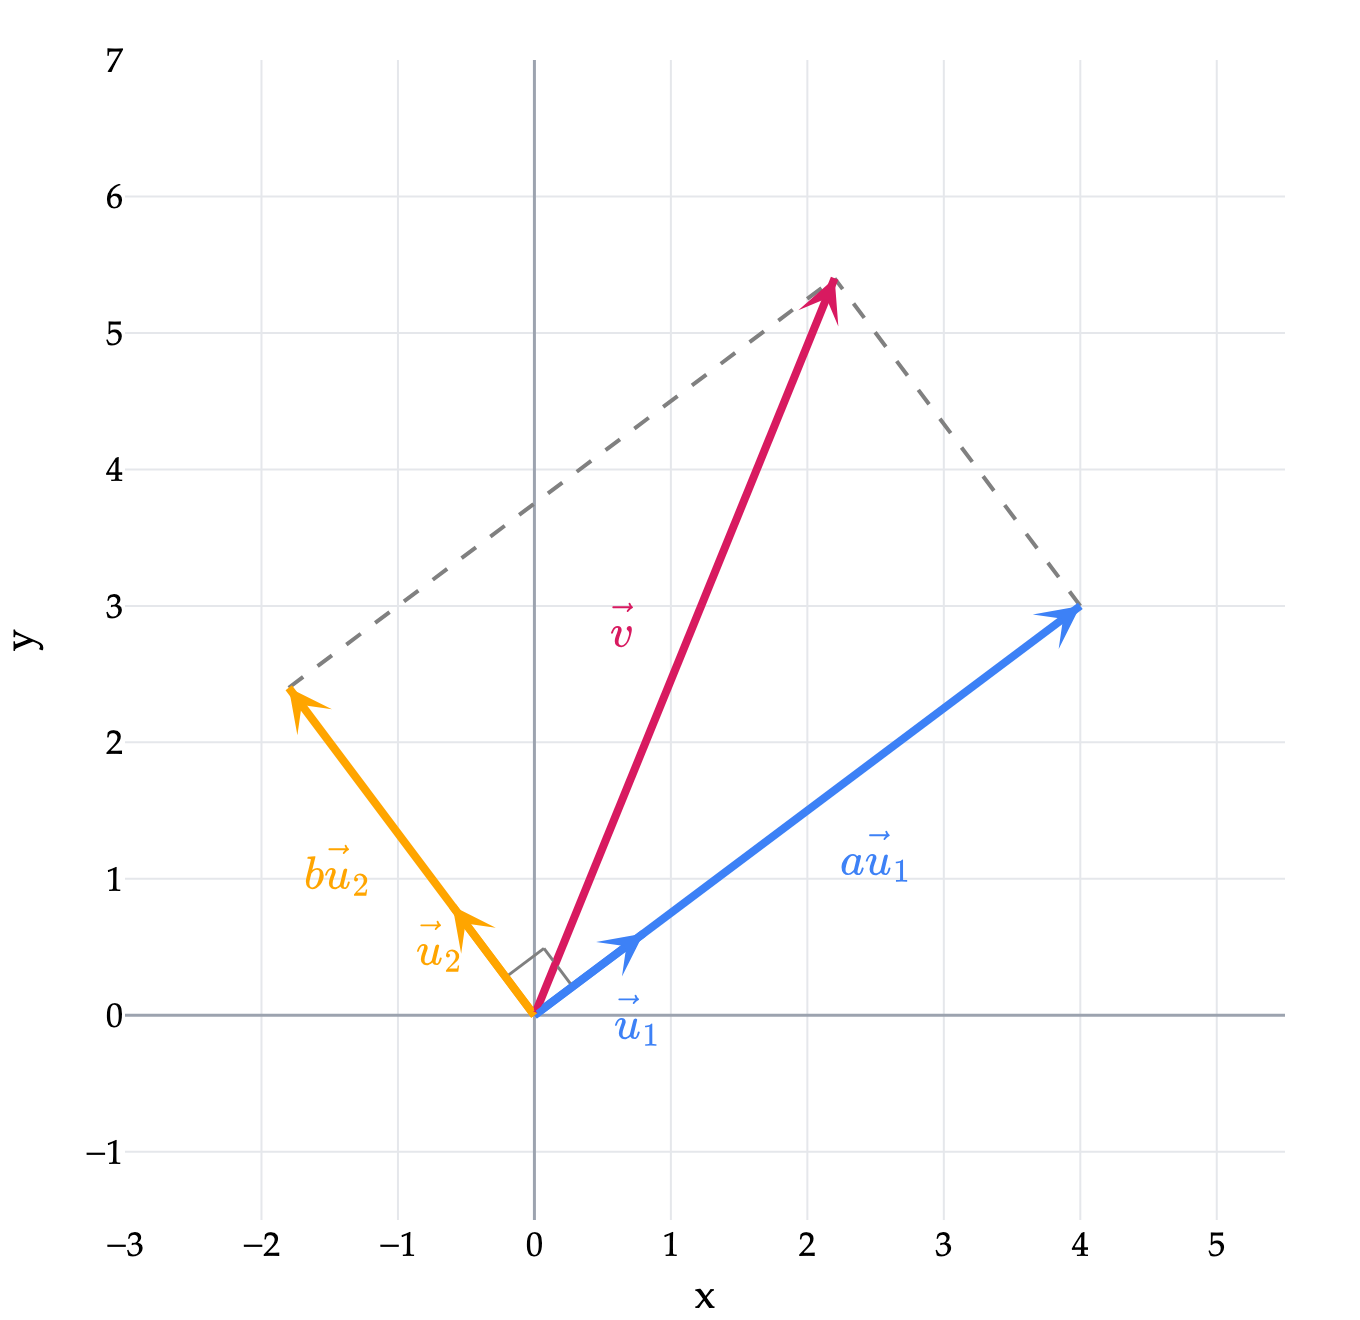

In [6]:
fig=base2((-3,5.5),(-1.5,7),width=680,height=660)
u1=np.array([4/5,3/5]); u2=np.array([-3/5,4/5])
a,b=5,3
p=a*u1; q=b*u2; v=p+q
line2(fig,p,v,'gray','dash'); line2(fig,q,v,'gray','dash')
vec2(fig,p,r"$a\vec u_1$",BLUE,dx=0.5,dy=-0.3)
vec2(fig,q,r"$b\vec u_2$",ORANGE,dx=-0.55,dy=-0.1)
vec2(fig,v,r"$\vec v$",PINK,dx=-0.45,dy=0.2)
square2(fig,(0,0),u1,u2,0.35)
vec2(fig,u1,r"$\vec u_1$",BLUE,dx=0.35,dy=-0.3)
vec2(fig,u2,r"$\vec u_2$",ORANGE,dx=-0.4,dy=0.15)
fig.show(scale=2)

```{figure} #plot-22-18
:label: fig-plot-22-18
:class: course-caption
:alt: The decomposition
$\vec v=a\vec u_1+b\vec u_2$ with respect to the orthonormal directions
$\vec u_1$ and $\vec u_2$.

The decomposition
$\vec v=a\vec u_1+b\vec u_2$ with respect to the orthonormal directions
$\vec u_1$ and $\vec u_2$.
```

But how do we find $a,b$?

The distributive and scalar-multiplication properties from [Chapter 1.6](../ch01/01-06.ipynb) let us isolate one coefficient at a time. Take the dot product with $\vec u_1$:

$$
\vec v\cdot \vec u_1
=
(a\vec u_1+b\vec u_2)\cdot \vec u_1
=
a(\vec u_1\cdot \vec u_1)
+
b(\vec u_2\cdot \vec u_1).
$$

Since $\vec u_1$ is a unit vector,

$$
\vec u_1\cdot \vec u_1=1.
$$

Since $\vec u_1$ and $\vec u_2$ are orthogonal,

$$
\vec u_2\cdot \vec u_1=0.
$$

Therefore

$$
\vec v\cdot \vec u_1=a.
$$

Similarly,

$$
b=\vec v\cdot \vec u_2.
$$

So

$$
\vec v
=
(\vec v\cdot \vec u_1)\vec u_1
+
(\vec v\cdot \vec u_2)\vec u_2.
$$

:::{note} Coefficients in an orthonormal basis
If $(\vec u_1,\vec u_2)$ is an orthonormal basis of $\mathbb R^2$, then

$$\vec v=(\vec v\cdot\vec u_1)\vec u_1+(\vec v\cdot\vec u_2)\vec u_2.$$

The coefficients are scalars; multiplying each by its basis vector gives a vector component. A negative coefficient means that component points opposite to the basis vector.
:::


---

## Representing the same vector in different bases

Let

$$
\vec v=
\begin{bmatrix}
7\\
5
\end{bmatrix}.
$$

### Using the standard basis

For the standard basis

$$
(\vec e_1,\vec e_2)
=
\left(
\begin{bmatrix}
1\\
0
\end{bmatrix},
\begin{bmatrix}
0\\
1
\end{bmatrix}
\right),
$$

we have

$$
\vec v\cdot \vec e_1
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
1\\
0
\end{bmatrix}
=
7,
$$

and

$$
\vec v\cdot \vec e_2
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
5.
$$

Therefore

$$
(\vec v\cdot \vec e_1)\vec e_1
+
(\vec v\cdot \vec e_2)\vec e_2
=
7\vec e_1+5\vec e_2
=
\begin{bmatrix}
7\\
0
\end{bmatrix}
+
\begin{bmatrix}
0\\
5
\end{bmatrix}
=
\begin{bmatrix}
7\\
5
\end{bmatrix}.
$$

### Using a different orthonormal basis

Now take the orthonormal basis

$$
(\vec u_1,\vec u_2)
=
\left(
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix},
\begin{bmatrix}
-\frac35\\[2pt]
\frac45
\end{bmatrix}
\right).
$$

Then

$$
\vec v\cdot \vec u_1
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix}
=
\frac{28}{5}+\frac{15}{5}
=
\frac{43}{5}.
$$

Also,

$$
\vec v\cdot \vec u_2
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac35\\[2pt]
\frac45
\end{bmatrix}
=
-\frac{21}{5}+\frac{20}{5}
=
-\frac15.
$$

So

$$
\vec v
=
\frac{43}{5}\vec u_1
-
\frac15 \vec u_2.
$$

The coefficient $-1/5$ means the second component points opposite to $\vec u_2$. The vector itself is still $\begin{bmatrix}7\\5\end{bmatrix}$.

::::{tip} Activity 1


Continuing the example, suppose

$$
(\vec w_1,\vec w_2)
=
\left(
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
\frac{1}{\sqrt{2}}
\end{bmatrix},
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}
\right).
$$

Let

$$
\vec v=
\begin{bmatrix}
7\\
5
\end{bmatrix}.
$$


Find the coefficients of $\vec v$ in this orthonormal basis. What changes, and what stays the same?

:::{tip} Solution
:class: dropdown

$$
\vec v\cdot \vec w_1
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
\frac{1}{\sqrt{2}}
\end{bmatrix}
=
-\frac{7}{\sqrt{2}}+\frac{5}{\sqrt{2}}
=
-\frac{2}{\sqrt{2}}
=
-\sqrt{2}.
$$

Also,

$$
\vec v\cdot \vec w_2
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}
=
-\frac{7}{\sqrt{2}}-\frac{5}{\sqrt{2}}
=
-\frac{12}{\sqrt{2}}
=
-6\sqrt{2}.
$$

So

$$
\vec v
=
-\sqrt{2}\,\vec w_1
-
6\sqrt{2}\,\vec w_2.
$$

The vector is the same in all three cases. Its coefficients change because we are describing it using different pairs of directions.
:::
::::